# Claude Code From Scratch — v3: the same coding agent, rebuilt on **LangGraph**

> **Sibling notebooks.** `claude_code_from_scratch_v1` hand-rolls a single tool loop;
> `…_v2` adds the article's reliability stack (test-time compute, planning, a bounded
> context window, a five-subagent architecture) — all on a hand-written `master_loop`
> over Ollama's raw `/api/chat`. **This is v3:** the *same* capabilities and the *same*
> phase structure, but the agent is now a **LangGraph** application.

What changes when we move to LangGraph:

| concern | v2 (from scratch) | v3 (LangGraph) |
|---|---|---|
| the loop | `master_loop()` while-loop | a `StateGraph`: `agent` node ⇄ `ToolNode`, routed by `tools_condition` |
| the model | `requests.post(/api/chat)` | `ChatOllama` + `.bind_tools()` / `.with_structured_output()` |
| tools | dict dispatch | `@tool`-decorated functions in a `ToolNode` |
| subagents | recursive `spawn_subagent()` | compiled subgraphs exposed as **agent-as-tool** |
| durable state | a sqlite DAG + custom memory | the same, plus a graph **checkpointer** (resume / time-travel) |
| context window | manual trim in the loop | a `pre_model_hook` on the graph |
| the team | hand-routed five subagents | a multi-node graph with conditional edges (the DAG *is* the topology) |
| observability | a `rich` tracer wrapping every call | a `BaseCallbackHandler` LangChain emits into, + `graph.stream(...)` + graph diagrams |

Everything still runs locally against **Ollama** with **qwen3** (a thinking model). The
phases below mirror v2 one-for-one so you can read them side by side.

## Phase 0 — Setup: imports, logging, config, and the model factory

In [1]:
"""
Imports. The only new dependencies vs v2 are the LangGraph / LangChain stack:
  langgraph, langchain-core, langchain-ollama  (pip install -U langgraph langchain-ollama)
Everything else (sqlite, subprocess, ast, py_compile) is standard-library, exactly as v2.
"""
from __future__ import annotations

import ast
import importlib.util
import json
import logging
import os
import py_compile
import re
import sqlite3
import subprocess
import sys
import tempfile
import time
import uuid
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass, field
from pathlib import Path
from typing import Annotated, Any, Callable, Dict, List, Literal, Optional, TypedDict
import glob as _glob

from pydantic import BaseModel, Field

# --- LangChain / LangGraph ---------------------------------------------------
from langchain_core.messages import (AIMessage, AnyMessage, BaseMessage, HumanMessage,
                                     RemoveMessage, SystemMessage, ToolMessage, trim_messages)
from langchain_core.tools import tool
from langchain_core.callbacks import BaseCallbackHandler
from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition, create_react_agent
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

In [2]:
"""
Logging -- one "agent3" logger with per-subsystem children, mirroring v2's style so the
two notebooks read the same. Set AGENT_LOG_LEVEL=DEBUG for full payloads.
"""
AGENT_LOG_LEVEL = os.environ.get("AGENT_LOG_LEVEL", "INFO").upper()


class _Fmt(logging.Formatter):
    COLORS = {"DEBUG": "\033[90m", "INFO": "\033[36m", "WARNING": "\033[33m",
              "ERROR": "\033[31m", "CRITICAL": "\033[41m"}
    RESET = "\033[0m"
    def format(self, record: logging.LogRecord) -> str:
        color = self.COLORS.get(record.levelname, "")
        short = record.name.split(".", 1)[1] if "." in record.name else record.name
        return f"{color}[{record.levelname:5s}] {short:16s} | {record.getMessage()}{self.RESET}"


_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(_Fmt())
log = logging.getLogger("agent3")
log.handlers.clear()
log.addHandler(_handler)
log.setLevel(AGENT_LOG_LEVEL)
log.propagate = False

log_llm   = logging.getLogger("agent3.llm")
log_tool  = logging.getLogger("agent3.tool")
log_graph = logging.getLogger("agent3.graph")
log_sub   = logging.getLogger("agent3.subagent")
log.info(f"Logger initialised at level {AGENT_LOG_LEVEL}")

[INFO ] agent3           | Logger initialised at level INFO


In [3]:
"""
Configuration -- every knob lives here. Backend note: v3 talks to Ollama through
ChatOllama (LangChain). To use a different OpenAI-compatible backend, swap the model
factory `llm()` in the next cell and the MODELS map -- the graphs do not change.
"""

# --- Ollama endpoint ---------------------------------------------------------
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:8080")

# --- Model per role (same split as v1/v2) ------------------------------------
MODELS = {
    "reasoning":  os.environ.get("AGENT3_REASONING_MODEL",  "qwen3:32b"),
    "fast":       os.environ.get("AGENT3_FAST_MODEL",       "qwen3:8b"),
    "summarizer": os.environ.get("AGENT3_SUMMARIZER_MODEL", "qwen3:8b"),
}
MODEL_REASONING = MODELS["reasoning"]
MODEL_FAST      = MODELS["fast"]

# --- Sandbox workspace -------------------------------------------------------
WORKSPACE = Path(os.environ.get("AGENT3_WORKSPACE",
                                str(Path.cwd() / "v3_workspace"))).resolve()
WORKSPACE.mkdir(parents=True, exist_ok=True)
AGENT_CODE_DIR = WORKSPACE / "agent_code"
AGENT_CODE_DIR.mkdir(exist_ok=True)
DB_PATH = WORKSPACE / "dag.db"

# --- Limits ------------------------------------------------------------------
MAX_TOOL_OUTPUT   = 12_000
BASH_TIMEOUT_S    = 60
TEST_TIMEOUT_S    = 120
REQUEST_TIMEOUT_S = 900       # 32b can be slow on a big context
MAX_ITERATIONS    = 20

BASH_BLOCKLIST = ["rm -rf /", "sudo", "shutdown", "reboot", "mkfs", "> /dev/", ":(){ :|:& };:"]
_HAS_PYTEST = importlib.util.find_spec("pytest") is not None

log.info(f"OLLAMA_HOST = {OLLAMA_HOST}")
log.info(f"MODELS      = {MODELS}")
log.info(f"WORKSPACE   = {WORKSPACE}")
log.info(f"pytest available for spec layer: {_HAS_PYTEST}")

[INFO ] agent3           | OLLAMA_HOST = http://localhost:8080
[INFO ] agent3           | MODELS      = {'reasoning': 'qwen3:32b', 'fast': 'qwen3:8b', 'summarizer': 'qwen3:8b'}
[INFO ] agent3           | WORKSPACE   = /home/bmartins/dev/agentic_patterns/src/code_assistant/v3_workspace
[INFO ] agent3           | pytest available for spec layer: False


In [4]:
"""
The model factory -- the single place a chat model is built.

`llm(role, **opts)` returns a configured ChatOllama. qwen3 is a *thinking* model;
langchain-ollama surfaces the thinking channel separately:
  reasoning=True  -> <think> goes to msg.additional_kwargs["reasoning_content"],
                     the visible answer is msg.content   (we use this for free-text)
  reasoning=False -> thinking disabled; best for JSON / structured calls (faster)

We cache one client per (model, reasoning, temperature, num_predict) so repeated calls
reuse the same connection.
"""
from functools import lru_cache


@lru_cache(maxsize=32)
def _client(model: str, reasoning: Optional[bool], temperature: float,
            num_predict: Optional[int]) -> ChatOllama:
    kw: Dict[str, Any] = dict(model=model, base_url=OLLAMA_HOST, temperature=temperature,
                              reasoning=reasoning, client_kwargs={"timeout": REQUEST_TIMEOUT_S})
    if num_predict:
        kw["num_predict"] = num_predict
    return ChatOllama(**kw)


def llm(role: str = "fast", *, reasoning: Optional[bool] = True,
        temperature: float = 0.2, max_tokens: Optional[int] = None) -> ChatOllama:
    """Get a chat model by ROLE ('reasoning' | 'fast' | 'summarizer') or an explicit model name."""
    model = MODELS.get(role, role)
    return _client(model, reasoning, temperature, max_tokens)


def ollama_healthcheck() -> bool:
    """Tags-only probe (no generation): is the server up and are our models present?"""
    import requests
    try:
        r = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=5)
        r.raise_for_status()
        tags = [m["name"] for m in r.json().get("models", [])]
        log_llm.info(f"healthcheck OK -- {len(tags)} models available")
        for role, name in MODELS.items():
            present = any(t == name or t.startswith(name.split(':')[0] + ":") for t in tags)
            log_llm.info(f"   {role:11s} {name:12s} [{'OK' if present else 'MISSING'}]")
        return True
    except Exception as e:
        log_llm.error(f"healthcheck FAILED: {e}")
        return False

log.info("Model factory ready: llm('reasoning'|'fast'|'summarizer'). Run ollama_healthcheck() to probe.")

[INFO ] agent3           | Model factory ready: llm('reasoning'|'fast'|'summarizer'). Run ollama_healthcheck() to probe.


## Phase 0.5 — Observability: a callback handler LangChain narrates into

v2 wrapped every model/tool call in a `rich` tracer. In LangGraph the idiomatic seam is a
**`BaseCallbackHandler`**: LangChain calls our hooks on every model start/stop and tool
start/stop, so we get the same nested narrative for free, no matter how deep the graph
nests. We also add two LangGraph-native views:

* `show_graph(app)` — draw any compiled graph as a Mermaid/ASCII diagram, and
* `stream_run(app, inputs, ...)` — run a graph and print each node's update as it streams.

Drive it with `AGENT_TRACE=full|compact|off`. Pass `config=run_config("label")` (or just
`CB`) when you `.invoke` / `.stream` a graph and every step is traced.

In [5]:
"""
RichTracer -- a LangChain callback handler. It prints, for every model call: the prompt
tail, the <think> channel, the answer, any tool calls; and for every tool: args + result.
Falls back to plain logging if `rich` is absent. Thread-safe token/call counters.

Because LangChain drives the hooks, this works identically for a bare llm.invoke(), a
ToolNode, a create_react_agent, or the deep five-subagent graph in Phase 7.
"""
import threading

TRACE_LEVEL   = os.environ.get("AGENT_TRACE", "full").lower()
TRACE_PREVIEW = int(os.environ.get("AGENT_TRACE_PREVIEW", "1600"))

try:
    from rich.console import Console
    from rich.panel import Panel
    from rich.text import Text
    from rich.table import Table
    _HAS_RICH = True
    _console = Console(highlight=False, soft_wrap=True)
except Exception:
    _HAS_RICH = False
    _console = None


def _clip(s, n=None):
    s = "" if s is None else str(s)
    n = n or TRACE_PREVIEW
    return s if len(s) <= n else s[:n] + f"\n... [+{len(s) - n} chars]"


def thinking_of(msg: BaseMessage) -> str:
    """qwen3's reasoning channel (langchain-ollama puts it in additional_kwargs)."""
    ak = getattr(msg, "additional_kwargs", {}) or {}
    return ak.get("reasoning_content") or ak.get("thinking") or ""


class RichTracer(BaseCallbackHandler):
    def __init__(self):
        self._lock = threading.Lock()
        self.calls = 0
        self.tokens = 0
        self.tool_calls = 0
        self._starts = {}

    @property
    def on(self):
        return TRACE_LEVEL != "off"

    @property
    def full(self):
        return TRACE_LEVEL == "full"

    def _emit(self, renderable, plain):
        if not self.on:
            return
        if _HAS_RICH:
            _console.print(renderable)
        else:
            log_llm.info(plain)

    # --- model -------------------------------------------------------------
    def on_chat_model_start(self, serialized, messages, *, run_id=None, **kw):
        with self._lock:
            self.calls += 1
            n = self.calls
        self._starts[run_id] = time.time()
        if not self.on:
            return
        last = messages[0][-1] if messages and messages[0] else None
        tail = getattr(last, "content", "") if last else ""
        self._emit(Text(f">> #{n} model call", style="bold cyan") if _HAS_RICH
                   else f">> #{n} model call", f">> #{n} model call")
        if self.full and tail:
            self._emit(Panel(Text(_clip(tail)), title=f"#{n} prompt tail",
                             title_align="left", border_style="cyan") if _HAS_RICH else None,
                       f"   prompt: {_clip(tail, 200)}")

    def on_llm_end(self, response, *, run_id=None, **kw):
        dt = time.time() - self._starts.pop(run_id, time.time())
        try:
            gen = response.generations[0][0]
            msg = getattr(gen, "message", None)
            text = getattr(msg, "content", "") if msg else getattr(gen, "text", "")
            think = thinking_of(msg) if msg else ""
            usage = (getattr(msg, "usage_metadata", None) or {}) if msg else {}
            tok = usage.get("output_tokens", 0) or 0
            tcs = getattr(msg, "tool_calls", []) if msg else []
        except Exception:
            text, think, tok, tcs = "", "", 0, []
        with self._lock:
            self.tokens += tok
        if not self.on:
            return
        if self.full and think:
            self._emit(Panel(Text(_clip(think), style="italic"), title="thinking",
                             title_align="left", border_style="grey50") if _HAS_RICH else None,
                       f"[think] {_clip(think, 300)}")
        if text:
            self._emit(Panel(Text(_clip(text)), title=f"answer ({dt:.1f}s, {tok} tok)",
                             title_align="left", border_style="green") if _HAS_RICH else None,
                       f"[answer] {_clip(text, 300)}")
        for tc in tcs or []:
            nm = tc.get("name", "?")
            self._emit(Text(f"-> wants tool: {nm}({_clip(json.dumps(tc.get('args', {}), default=str), 160)})",
                            style="bold yellow") if _HAS_RICH else None,
                       f"-> tool {nm}")

    # --- tools -------------------------------------------------------------
    def on_tool_start(self, serialized, input_str, *, run_id=None, **kw):
        with self._lock:
            self.tool_calls += 1
        name = (serialized or {}).get("name", "tool")
        self._emit(Panel(Text(_clip(input_str, 800)), title=f"tool: {name} (args)",
                         title_align="left", border_style="yellow") if _HAS_RICH else None,
                   f"[tool] {name}({_clip(input_str, 120)})")

    def on_tool_end(self, output, *, run_id=None, **kw):
        text = str(getattr(output, "content", output))
        err = text.lstrip().lower().startswith(("error", "[error", "reverted", "traceback"))
        self._emit(Panel(Text(_clip(text)), title="tool result",
                         title_align="left", border_style="red" if err else "green") if _HAS_RICH else None,
                   ("[fail] " if err else "[ok] ") + _clip(text, 200))

    def event(self, title, body="", style="bold blue"):
        if not self.on:
            return
        if _HAS_RICH:
            t = Text(title, style=style)
            if body:
                t.append("\n" + _clip(body))
            _console.print(Panel(t, border_style="blue", title_align="left"))
        else:
            log.info(f"[event] {title} -- {_clip(body, 200)}")

    def summary(self):
        if _HAS_RICH:
            t = Table(title="Trace summary")
            t.add_column("metric"); t.add_column("value", justify="right")
            t.add_row("model calls", str(self.calls))
            t.add_row("output tokens", str(self.tokens))
            t.add_row("tool calls", str(self.tool_calls))
            _console.print(t)
        else:
            log.info(f"TRACE: {self.calls} calls, {self.tokens} tok, {self.tool_calls} tools")


tracer = RichTracer()
CB = {"callbacks": [tracer]}   # pass as config to .invoke/.stream to trace a run


def run_config(label: str = "run", **extra) -> dict:
    """A LangGraph run config that traces (callbacks) and carries a thread id for checkpointing."""
    cfg = {"callbacks": [tracer], "configurable": {"thread_id": f"{label}-{uuid.uuid4().hex[:6]}"}}
    cfg.update(extra)
    return cfg

log.info(f"Tracer ready (AGENT_TRACE={TRACE_LEVEL}, rich={_HAS_RICH}). Pass CB or run_config(..) when you invoke a graph.")

[INFO ] agent3           | Tracer ready (AGENT_TRACE=full, rich=True). Pass CB or run_config(..) when you invoke a graph.


In [6]:
"""
Two LangGraph-native views: a diagram of any compiled graph, and a streaming pretty-printer.
"""
from IPython.display import Image, display


def show_graph(app, title: str = ""):
    """Render a compiled graph as a Mermaid PNG (falls back to ASCII art)."""
    if title:
        log_graph.info(f"graph: {title}")
    g = app.get_graph()
    try:
        return Image(g.draw_mermaid_png())
    except Exception:
        print(g.draw_ascii())
        return None


def stream_run(app, inputs, config=None, *, mode: str = "updates"):
    """Run a graph and print each node update as it streams. Returns the final state."""
    config = config or run_config("stream")
    final = None
    for chunk in app.stream(inputs, config=config, stream_mode=mode):
        for node, update in chunk.items():
            msgs = (update or {}).get("messages") if isinstance(update, dict) else None
            tail = ""
            if msgs:
                last = msgs[-1]
                tail = thinking_of(last) and "[+think] " or ""
                tail += _clip(getattr(last, "content", ""), 200)
            log_graph.info(f"· node «{node}» -> {tail or list((update or {}).keys())}")
            final = update
    return final

log.info("Observability ready: show_graph(app), stream_run(app, inputs), tracer.summary().")

[INFO ] agent3           | Observability ready: show_graph(app), stream_run(app, inputs), tracer.summary().


## Phase 1 — Cognitive substrate: thinking, structured routing, test-time compute

The same reasoning primitives as v2, expressed with LangChain idioms:

* **thinking** comes from `reasoning=True` (qwen3's channel lands in `additional_kwargs`);
* **structured routing** (`estimate_difficulty`, `classify_problem`) uses
  `llm.with_structured_output(PydanticModel)` instead of hand-parsing JSON;
* **test-time compute** (`self_consistency`, `asymmetric_solve`, `adaptive_think`) uses
  `llm.batch([...])` to sample in parallel.

In [7]:
STRONG_SYSTEM_PROMPT = (
    "You are a careful, senior software-engineer agent. You think before you act. "
    "You write code that is verifiable, not impressive. You name your assumptions "
    "before you commit to them.\n\n"
    "RULES OF ENGAGEMENT:\n"
    "1. Never claim a behaviour without a runnable artefact (a test, a run) backing it.\n"
    "2. Defer all questions about what the code does to actually executing it.\n"
    "3. When a test or a linter disagrees with you, it is correct until you produce evidence.\n"
    "4. If you do not know how to do something, say so. Do not guess.\n"
    "5. The spec / definition-of-done is the source of truth, not your opinion of your work."
)

# qwen3 may still emit literal <think>..</think> in content on some paths; keep tolerant parsers.
_THINK_RE = re.compile(r"<think>(.*?)</think>", re.DOTALL)


def strip_think(text: str) -> str:
    return _THINK_RE.sub("", text or "").strip()


def split_think(msg) -> tuple[str, str]:
    """Return (thinking, answer) for an AIMessage or a raw string."""
    if isinstance(msg, BaseMessage):
        think = thinking_of(msg)
        content = msg.content or ""
        if think:
            return think, strip_think(content)
        m = _THINK_RE.search(content)
        return (m.group(1).strip() if m else ""), strip_think(content)
    text = msg or ""
    m = _THINK_RE.search(text)
    return (m.group(1).strip() if m else ""), strip_think(text)

log.info("Substrate constants ready: STRONG_SYSTEM_PROMPT, strip_think/split_think.")

[INFO ] agent3           | Substrate constants ready: STRONG_SYSTEM_PROMPT, strip_think/split_think.


In [8]:
@dataclass
class ThoughtfulResponse:
    thinking: str
    answer: str
    output_tokens: int


def think_then_answer(query: str, role: str = "fast", temperature: float = 0.3,
                      max_tokens: int = 2048, system: str = STRONG_SYSTEM_PROMPT) -> ThoughtfulResponse:
    """One free-text call with the thinking channel separated out (v2's primitive, on ChatOllama)."""
    model = llm(role, reasoning=True, temperature=temperature, max_tokens=max_tokens)
    msg = model.invoke([SystemMessage(system), HumanMessage(query)], config=CB)
    thinking, answer = split_think(msg)
    usage = getattr(msg, "usage_metadata", None) or {}
    return ThoughtfulResponse(thinking=thinking, answer=answer,
                              output_tokens=usage.get("output_tokens", 0))

log.info("think_then_answer ready.")

[INFO ] agent3           | think_then_answer ready.


In [9]:
"""
Structured routing -- two cheap classifiers via with_structured_output. Pydantic schemas
replace v2's hand-rolled JSON prompts + tolerant parsing: the framework constrains the
model and validates the result for us.
"""

THINKING_BUDGETS = {"trivial": 256, "easy": 512, "medium": 1500, "hard": 3000, "extreme": 6000}
PROBLEM_TYPES = ["convergent", "divergent", "exploratory", "structural"]
TYPE_STRATEGY = {"convergent": "self_consistency", "divergent": "asymmetric_solve",
                 "exploratory": "wide_pass", "structural": "decompose"}


class Difficulty(BaseModel):
    difficulty: Literal["trivial", "easy", "medium", "hard", "extreme"]


class ProblemKind(BaseModel):
    type: Literal["convergent", "divergent", "exploratory", "structural"]
    reason: str = Field(description="one sentence")


def estimate_difficulty(query: str) -> str:
    model = llm("fast", reasoning=False, temperature=0.0).with_structured_output(Difficulty)
    try:
        return model.invoke([SystemMessage("Classify the difficulty of the task."),
                             HumanMessage(query)], config=CB).difficulty
    except Exception:
        return "medium"


def classify_problem(query: str) -> dict:
    sys_p = ("Classify the KIND of problem (not its difficulty).\n"
             "convergent  = one correct/defensible answer (a fact, a calculation, a fix).\n"
             "divergent   = many valid answers (designs, strategies, recommendations).\n"
             "exploratory = open-ended / under-specified (research, implications).\n"
             "structural  = needs decomposition into parts before answering (multi-step builds).")
    model = llm("fast", reasoning=False, temperature=0.0).with_structured_output(ProblemKind)
    try:
        r = model.invoke([SystemMessage(sys_p), HumanMessage(query)], config=CB)
        return {"type": r.type, "reason": r.reason}
    except Exception:
        return {"type": "convergent", "reason": "fallback (classifier failed)"}

log.info("Routers ready: estimate_difficulty, classify_problem.")

[INFO ] agent3           | Routers ready: estimate_difficulty, classify_problem.


In [10]:
"""
Test-time compute. self_consistency / asymmetric_solve sample candidates in parallel with
llm.batch(), then aggregate. adaptive_think routes difficulty->budget and type->strategy.
"""


class Verdict(BaseModel):
    score: int = Field(ge=1, le=10)
    reason: str


def self_consistency(query: str, k: int = 3, role: str = "fast") -> dict:
    model = llm(role, reasoning=True, temperature=0.7, max_tokens=1500)
    batch = [[SystemMessage(STRONG_SYSTEM_PROMPT), HumanMessage(query)] for _ in range(k)]
    outs = model.batch(batch, config=CB)
    samples = [strip_think(m.content) for m in outs]
    keys = [s[:60].lower() for s in samples]
    winner_key, votes = Counter(keys).most_common(1)[0]
    winner = next(s for s in samples if s[:60].lower() == winner_key)
    tracer.event(f"self-consistency: {votes}/{k} agree ({votes/k:.0%})", winner[:200])
    return {"winner": winner, "votes": votes, "k": k, "agreement": votes / k, "all_samples": samples}


def verifier_score(question: str, candidate: str, role: str = "reasoning") -> dict:
    model = llm(role, reasoning=False, temperature=0.0).with_structured_output(Verdict)
    try:
        v = model.invoke([SystemMessage("You are a careful verifier. Score FACTS and correctness, "
                                        "not style, 1-10."),
                          HumanMessage(f"QUESTION:\n{question}\n\nCANDIDATE:\n{candidate}")], config=CB)
        out = {"score": v.score, "reason": v.reason}
    except Exception as e:
        out = {"score": 0, "reason": f"verifier error: {e}"}
    tracer.event(f"verifier score: {out['score']}/10", out["reason"])
    return out


class Ranking(BaseModel):
    best_index: int
    reason: str


def asymmetric_solve(query: str, n_candidates: int = 3) -> dict:
    gen = llm("fast", reasoning=True, temperature=0.7, max_tokens=1500)
    cands = [strip_think(m.content) for m in
             gen.batch([[HumanMessage(query)] for _ in range(n_candidates)], config=CB)]
    ranker = llm("reasoning", reasoning=False).with_structured_output(Ranking)
    listing = "\n\n".join(f"CANDIDATE {i}:\n{c}" for i, c in enumerate(cands))
    try:
        r = ranker.invoke([HumanMessage("Pick the single best candidate.\n\n" + listing)], config=CB)
        idx = max(0, min(r.best_index, n_candidates - 1))
        tracer.event(f"asymmetry: picked #{idx} of {n_candidates}", r.reason)
        return {"winner": cands[idx], "winner_reason": r.reason, "candidates": cands}
    except Exception:
        return {"winner": cands[0], "winner_reason": "fallback", "candidates": cands}


def adaptive_think(query: str, route: bool = True) -> dict:
    difficulty = estimate_difficulty(query)
    budget = THINKING_BUDGETS.get(difficulty, 1500)
    problem = classify_problem(query) if route else {"type": "convergent", "reason": "routing off"}
    strategy = TYPE_STRATEGY.get(problem["type"], "self_consistency") if route else "single_pass"
    log.info(f"[adaptive] difficulty={difficulty} type={problem['type']} -> budget {budget}, {strategy}")
    tracer.event(f"adaptive route: {difficulty} / {problem['type']} -> {strategy}",
                 f"budget={budget}; {problem['reason']}")
    if strategy == "self_consistency":
        r = self_consistency(query, k=3); answer, extra = r["winner"], {"agreement": r["agreement"]}
    elif strategy == "asymmetric_solve":
        r = asymmetric_solve(query, 3); answer, extra = r["winner"], {"winner_reason": r["winner_reason"]}
    elif strategy == "decompose":
        r = think_then_answer("Break this into parts, solve each, then assemble:\n\n" + query,
                              max_tokens=budget); answer, extra = r.answer, {"tokens": r.output_tokens}
    elif strategy == "wide_pass":
        r = think_then_answer(query, temperature=0.7, max_tokens=max(budget, 3000))
        answer, extra = r.answer, {"tokens": r.output_tokens}
    else:
        r = think_then_answer(query, max_tokens=budget); answer, extra = r.answer, {"tokens": r.output_tokens}
    return {"difficulty": difficulty, "type": problem["type"], "budget": budget,
            "strategy": strategy, "answer": answer, **extra}

log.info("Test-time compute ready: self_consistency, verifier_score, asymmetric_solve, adaptive_think.")

[INFO ] agent3           | Test-time compute ready: self_consistency, verifier_score, asymmetric_solve, adaptive_think.


## Phase 2 — Tools: `@tool`-decorated, sandboxed to the workspace

v2 registered tools as a name→callable dict and hand-wrote JSON schemas. In v3 each tool is
a `@tool`-decorated function: LangChain derives the JSON schema from the **type hints and
docstring**, and a `ToolNode` (Phase 3) executes them. The bodies are the same sandboxed
file/shell/coding tools as v2 — paths confined to `WORKSPACE`, output truncated, writes
snapshotted, code writes lint-gated.

In [11]:
"""File & shell tools. Same sandboxing as v2; now exposed as LangChain tools."""

SNAPSHOTS: Dict[str, Optional[str]] = {}   # in-memory undo stack for revert


def _safe_path(path: str) -> Path:
    p = (WORKSPACE / path).resolve() if not os.path.isabs(path) else Path(path).resolve()
    try:
        p.relative_to(WORKSPACE)
    except ValueError:
        raise ValueError(f"path escapes WORKSPACE: {p}")
    return p


def _truncate(s: str, limit: int = MAX_TOOL_OUTPUT) -> str:
    return s if len(s) <= limit else s[:limit] + f"\n... [truncated {len(s) - limit} chars]"


@tool
def read_file(path: str, start_line: Optional[int] = None, end_line: Optional[int] = None) -> str:
    """Read a text file (relative to the workspace). Optional 1-indexed line range."""
    try:
        lines = _safe_path(path).read_text(encoding="utf-8", errors="replace").splitlines(keepends=True)
        i0 = max(0, (start_line or 1) - 1)
        i1 = end_line if end_line is not None else len(lines)
        return _truncate("".join(f"{i0+1+i:5d}\t{ln}" for i, ln in enumerate(lines[i0:i1])) or "(empty)")
    except FileNotFoundError:
        return f"Error: file not found: {path}"
    except Exception as e:
        return f"Error: {e}"


@tool
def write_file(path: str, content: str) -> str:
    """Write content to a file (snapshotted first; use revert_file to undo)."""
    try:
        p = _safe_path(path)
        SNAPSHOTS[str(p)] = p.read_text(encoding="utf-8", errors="replace") if p.exists() else None
        action = "updated" if SNAPSHOTS[str(p)] is not None else "created"
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(content, encoding="utf-8")
        log_tool.info(f"[write] {action} {p}")
        return f"{action}: {p} (snapshot saved -- use revert_file to undo)"
    except Exception as e:
        return f"Error: {e}"


@tool
def revert_file(path: str) -> str:
    """Undo the last write to a file from its snapshot."""
    try:
        p = _safe_path(path); key = str(p)
        if key not in SNAPSHOTS:
            return f"Error: no snapshot for {p}"
        prev = SNAPSHOTS.pop(key)
        if prev is None:
            p.unlink(missing_ok=True); return f"reverted: deleted {p} (was new)"
        p.write_text(prev, encoding="utf-8"); return f"reverted: {p}"
    except Exception as e:
        return f"Error: {e}"


@tool
def grep(pattern: str, path: str = ".", recursive: bool = True) -> str:
    """Regex search across files under a path (relative to the workspace)."""
    try:
        p = _safe_path(path)
        flags = ["-rn"] if recursive else ["-n"]
        proc = subprocess.run(["grep", *flags, pattern, str(p)],
                              capture_output=True, text=True, timeout=30)
        return _truncate((proc.stdout + proc.stderr).strip() or "(no matches)", 8000)
    except Exception as e:
        return f"Error: {e}"


@tool
def glob_files(pattern: str) -> str:
    """Find files matching a glob pattern, e.g. '**/*.py' (scoped to the workspace)."""
    full = str(WORKSPACE / pattern) if not os.path.isabs(pattern) else pattern
    matches = [m for m in sorted(_glob.glob(full, recursive=True))[:200]
               if Path(m).resolve().is_relative_to(WORKSPACE)]
    return "\n".join(matches) if matches else "(no matches)"


@tool
def bash(command: str) -> str:
    """Run a shell command in the workspace (blocklisted destructive commands are refused)."""
    log_tool.info(f"[bash] {command[:100]}")
    for bad in BASH_BLOCKLIST:
        if bad in command:
            return f"Error: blocked by safety policy (matched {bad!r})"
    try:
        p = subprocess.run(command, shell=True, cwd=str(WORKSPACE),
                           capture_output=True, text=True, timeout=BASH_TIMEOUT_S)
        return _truncate((p.stdout + p.stderr).strip() or "(no output)")
    except subprocess.TimeoutExpired:
        return f"Error: timeout after {BASH_TIMEOUT_S}s"
    except Exception as e:
        return f"Error: {e}"

log.info("File/shell tools ready: read_file, write_file, revert_file, grep, glob_files, bash")

[INFO ] agent3           | File/shell tools ready: read_file, write_file, revert_file, grep, glob_files, bash


In [12]:
"""Coding-specific tools: lint-gated write, python runner, test runner (v2 bodies, @tool-wrapped)."""


def lint_python(code: str) -> dict:
    """Lightweight static gate: must compile; flag bare excepts. (Plain fn -- reused internally.)"""
    errors = []
    with tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w") as tmp:
        tmp.write(code); tmp_path = tmp.name
    try:
        py_compile.compile(tmp_path, doraise=True)
    except py_compile.PyCompileError as e:
        errors.append(f"SyntaxError: {e}")
    finally:
        os.unlink(tmp_path)
    try:
        for node in ast.walk(ast.parse(code)):
            if isinstance(node, ast.ExceptHandler) and node.type is None:
                errors.append(f"Style: bare `except:` at line {node.lineno}")
    except SyntaxError:
        pass
    return {"passed": len(errors) == 0, "errors": errors}


def _run_tests(test_code: str, timeout: int = TEST_TIMEOUT_S) -> dict:
    """Write a test module and run it (pytest if available, else plain python). Plain fn."""
    f = WORKSPACE / "_spec_test.py"
    f.write_text(test_code, encoding="utf-8")
    cmd = ([sys.executable, "-m", "pytest", "-q", str(f)] if _HAS_PYTEST else [sys.executable, str(f)])
    try:
        p = subprocess.run(cmd, cwd=str(WORKSPACE), capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        return {"all_passed": False, "passed": 0, "failed": 0,
                "stdout": f"timeout after {timeout}s", "exit_code": -1}
    out = p.stdout + p.stderr
    mp, mf = re.search(r"(\d+) passed", out), re.search(r"(\d+) failed", out)
    return {"all_passed": p.returncode == 0,
            "passed": int(mp.group(1)) if mp else (0 if p.returncode else 1),
            "failed": int(mf.group(1)) if mf else (1 if p.returncode else 0),
            "stdout": _truncate(out, 4000), "exit_code": p.returncode}


@tool
def write_code(filename: str, content: str) -> str:
    """Write a bare *.py file under agent_code/ -- ONLY persists if it lints clean."""
    if not filename.endswith(".py") or "/" in filename or ".." in filename:
        return "ERROR: invalid filename (must be a bare *.py name)"
    res = lint_python(content)
    if not res["passed"]:
        return "REVERTED: linter rejected. errors:\n  " + "\n  ".join(res["errors"])
    path = AGENT_CODE_DIR / filename
    path.write_text(content, encoding="utf-8")
    log_tool.info(f"[write_code] wrote {path} ({len(content)} bytes, lint OK)")
    return f"WROTE {len(content)} bytes to {filename} (lint passed)"


@tool
def run_python(code: str) -> str:
    """Execute a Python snippet in the workspace (agent_code on sys.path); returns stdout/stderr."""
    f = WORKSPACE / "_run.py"
    f.write_text("import sys\nsys.path.insert(0, %r)\n" % str(AGENT_CODE_DIR) + code, encoding="utf-8")
    try:
        p = subprocess.run([sys.executable, str(f)], cwd=str(WORKSPACE),
                           capture_output=True, text=True, timeout=BASH_TIMEOUT_S)
        return _truncate(f"exit={p.returncode}\n" + (p.stdout + p.stderr).strip(), 8000)
    except subprocess.TimeoutExpired:
        return f"timeout after {BASH_TIMEOUT_S}s"


@tool
def run_tests(test_code: str) -> str:
    """Write a test module and run it; returns a pass/fail summary with output."""
    v = _run_tests(test_code)
    return (f"all_passed={v['all_passed']} passed={v['passed']} failed={v['failed']}\n"
            + v["stdout"])


# The base toolset every coding agent gets (file/shell + coding tools).
TOOLS_BASE = [read_file, write_file, revert_file, grep, glob_files, bash,
              write_code, run_python, run_tests]
TOOLS_BY_NAME = {t.name: t for t in TOOLS_BASE}
log.info(f"Coding tools ready. Base toolset: {list(TOOLS_BY_NAME)}")

[INFO ] agent3           | Coding tools ready. Base toolset: ['read_file', 'write_file', 'revert_file', 'grep', 'glob_files', 'bash', 'write_code', 'run_python', 'run_tests']


## Phase 3 — The tool loop, as a graph

v2's `master_loop()` was a hand-written *perception → action → observation* while-loop. In
LangGraph that loop **is the graph**: an `agent` node calls the tool-bound model, a
`ToolNode` executes whatever tools it requested, and `tools_condition` is the conditional
edge that either routes back to `tools` or ends the run. Compiling with a **checkpointer**
gives us durable state (resume a thread, inspect history) for free.

`subagent discipline` becomes the **agent-as-tool** pattern: a subagent is just another
compiled graph, wrapped as a `@tool` the parent can call. Its internal steps never leak
into the parent's context — only its final summary returns.

In [13]:
"""
build_agent_graph -- the v3 replacement for master_loop. A two-node StateGraph over the
built-in MessagesState:  START -> agent -> (tools_condition) -> tools -> agent -> ... -> END.

The agent node prepends the system prompt at call time (so it always leads, without being
stored repeatedly). Compiled with an InMemorySaver checkpointer so a run is a resumable
thread keyed by run_config(...)'s thread_id.
"""


def build_agent_graph(tools, system: str = STRONG_SYSTEM_PROMPT, role: str = "fast",
                      reasoning: bool = True, checkpointer=None):
    model = llm(role, reasoning=reasoning).bind_tools(tools)

    def agent_node(state: MessagesState):
        msgs = list(state["messages"])
        if not msgs or not isinstance(msgs[0], SystemMessage):
            msgs = [SystemMessage(system)] + msgs
        return {"messages": [model.invoke(msgs, config=CB)]}

    g = StateGraph(MessagesState)
    g.add_node("agent", agent_node)
    g.add_node("tools", ToolNode(tools))
    g.add_edge(START, "agent")
    g.add_conditional_edges("agent", tools_condition)   # -> "tools" or END
    g.add_edge("tools", "agent")
    return g.compile(checkpointer=checkpointer or InMemorySaver())


# The lead coding agent: the full base toolset, the strong system prompt.
coding_agent = build_agent_graph(TOOLS_BASE, system=STRONG_SYSTEM_PROMPT, role="fast")
log_graph.info(f"coding_agent compiled. nodes={list(coding_agent.get_graph().nodes)}")

[INFO ] graph            | coding_agent compiled. nodes=['__start__', 'agent', 'tools', '__end__']


In [14]:
"""
Subagent discipline = the agent-as-tool pattern.

`spawn_subagent` runs a focused sub-graph and returns ONLY its final message. `make_subagent_tool`
packages such a sub-graph as a @tool, so a parent agent can delegate by calling it like any
other tool (LangGraph runs the whole sub-graph inside that one tool call).
"""
from langchain_core.tools import StructuredTool

SUBAGENT_SYSTEM = (
    f"You are a focused subagent working in a sandbox at {WORKSPACE}. You have a single "
    "subtask. Use tools to investigate or modify files. When confident, reply with a "
    "concise, self-contained summary and STOP calling tools -- that final message is the "
    "ONLY thing the parent agent sees. Do not ask clarifying questions; make a reasonable "
    "assumption and proceed."
)


def spawn_subagent(prompt: str, tools=TOOLS_BASE, system: str = SUBAGENT_SYSTEM,
                   role: str = "fast") -> str:
    sub_id = uuid.uuid4().hex[:6]
    log_sub.info(f"[sub:{sub_id}] spawn -- {prompt[:80]!r}")
    graph = build_agent_graph(tools, system=system, role=role)
    out = graph.invoke({"messages": [HumanMessage(prompt)]},
                       config=run_config(f"sub:{sub_id}", recursion_limit=2 * MAX_ITERATIONS))
    for m in reversed(out["messages"]):
        if isinstance(m, AIMessage) and (m.content or "").strip():
            return strip_think(m.content)
    return "(subagent produced no output)"


def make_subagent_tool(name: str, description: str, system: str,
                       tools=TOOLS_BASE, role: str = "fast") -> StructuredTool:
    def _run(prompt: str) -> str:
        return spawn_subagent(prompt, tools=tools, system=system, role=role)
    return StructuredTool.from_function(_run, name=name, description=description)

log.info("Tool loop + subagents ready: build_agent_graph, spawn_subagent, make_subagent_tool.")

[INFO ] agent3           | Tool loop + subagents ready: build_agent_graph, spawn_subagent, make_subagent_tool.


[INFO ] graph            | graph: lead coding agent (agent <-> tools)


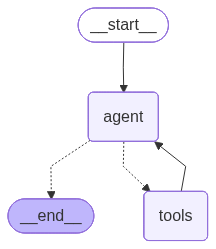

In [15]:
# [LIVE] Visualise the loop, then run the lead agent on a tiny task (needs Ollama up).
show_graph(coding_agent, "lead coding agent (agent <-> tools)")

In [16]:
# [LIVE] One real run, streamed node-by-node. Watch agent -> tools -> agent until it stops.
_final = stream_run(
    coding_agent,
    {"messages": [HumanMessage("Create hello.txt containing the text 'hi from v3', "
                               "then read it back to confirm.")]},
    config=run_config("demo-loop"))
print("\nFINAL:", strip_think(_final["messages"][-1].content)[:300])

>> #1 model call

╭─ #1 prompt tail ────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Create hello.txt containing the text 'hi from v3', then read it back to confirm.                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (8.1s, 402 tok) ────────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, let's tackle this user request. The user wants to create a file called hello.txt with the text 'hi from v │
│                                                                                                                 │
│ First, I need to use the write_file function to create the file. The parameters required are path and content.  │
│                                                                                                                 │
│ Next, to read the file back, I'll use the read_file function. The path is still "hello.txt". I need to make sur │
│                                                                                                                 │
│ Wait, the read_file function has optional start_line and end_line parameters. Since the user didn't specify lin │
│                                                                                                                 │
│ I should execute these two function calls in sequence. First, write the file, then read it. The user might expe │
│                                                                                                                 │
│ I need to make sure that the write_file is successful. Also, since the workspace might have existing files, but │
│                                                                                                                 │
│ So the steps are: call write_file with path hello.txt and content 'hi from v3', then call read_file with path h │
│ </think>                                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

-> wants tool: write_file({"content": "hi from v3", "path": "hello.txt"})

-> wants tool: read_file({"path": "hello.txt"})

...

[INFO ] graph            | · node «tools» ->     1	hi from v3


>> #2 model call

╭─ #2 prompt tail ────────────────────────────────────────────────────────────────────────────────────────────────╮
│     1   hi from v3                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (2.5s, 162 tok) ────────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, let me see. The user asked to create hello.txt with 'hi from v3' and then read it back. I called write_fi │
│ </think>                                                                                                        │
│                                                                                                                 │
│ The file `hello.txt` has been successfully created and verified:                                                │
│                                                                                                                 │
│ ```                                                                                                             │
│ hi from v3                                                                                                      │
│ ```                                                                                                             │
│                                                                                                                 │
│ The content matches the expected text. No further action required.                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO ] graph            | · node «agent» -> <think>
Okay, let me see. The user asked to create hello.txt with 'hi from v3' and then read it back. I called write_file first, which successfully created the file. Then I used read_file to check its
... [+534 chars]

FINAL: The file `hello.txt` has been successfully created and verified:

```
hi from v3
```

The content matches the expected text. No further action required.


## Phase 4 — The hardening stack, as small graphs

v2's hardening primitives were plain functions with internal loops. In v3 each one becomes a
tiny graph, which is exactly where LangGraph earns its keep — **loops and branches are edges**:

* **architect → editor**: a linear two-node chain (reason, then transcribe).
* **self-refine**: `generate → critique → refine` with a conditional edge that loops back
  to `critique` until the iteration budget is spent.
* **code-with-tests**: `generate → verify`, where `verify` either ends (tests pass) or loops
  back to `generate` with the failure as feedback.
* **adversarial probe**: one structured-output call that returns a typed list of attacks.

In [17]:
"""architect -> editor: the reasoning model plans (structured), the fast model transcribes."""


class Section(BaseModel):
    section: str
    intent: str
    key_constraints: List[str] = Field(default_factory=list)


class ArchitectPlan(BaseModel):
    plan: List[Section]


class _AEState(TypedDict):
    task: str
    plan: dict
    output: str


def _architect_node(state: _AEState):
    model = llm("reasoning", reasoning=True, temperature=0.2).with_structured_output(ArchitectPlan)
    try:
        plan = model.invoke([SystemMessage("You are a senior architect. Produce a STRUCTURED PLAN "
                                           "the editor will implement -- not the final code."),
                             HumanMessage(f"TASK:\n{state['task']}")], config=CB)
        pd = plan.model_dump()
    except Exception:
        pd = {"plan": []}
    tracer.event(f"architect plan: {len(pd.get('plan', []))} section(s)",
                 ", ".join(s["section"] for s in pd.get("plan", [])))
    return {"plan": pd}


def _editor_node(state: _AEState):
    # /no_think: the architect already deliberated; the editor just transcribes the plan to output.
    model = llm("fast", reasoning=False, temperature=0.3, max_tokens=3072)
    msg = model.invoke([SystemMessage("You are an editor. Execute the architect's plan precisely. "
                                      "Do NOT redesign. Output the final result only."),
                        HumanMessage(f"TASK:\n{state['task']}\n\nPLAN:\n{json.dumps(state['plan'], indent=2)}"
                                     "\n\nProduce the final output now.")], config=CB)
    return {"output": strip_think(msg.content)}


_ae = StateGraph(_AEState)
_ae.add_node("architect", _architect_node); _ae.add_node("editor", _editor_node)
_ae.add_edge(START, "architect"); _ae.add_edge("architect", "editor"); _ae.add_edge("editor", END)
architect_editor_app = _ae.compile()


def architect_editor_solve(task: str) -> dict:
    out = architect_editor_app.invoke({"task": task}, config=CB)
    return {"plan": out.get("plan", {}), "output": out.get("output", "")}

log_graph.info("architect_editor_app compiled (architect -> editor).")

[INFO ] graph            | architect_editor_app compiled (architect -> editor).


In [18]:
"""self-refine: generate -> critique -> refine, looping until the iteration budget is spent."""


class _RefineState(TypedDict):
    query: str
    current: str
    critique: str
    iteration: int
    max_iter: int
    history: List[dict]


def _gen_node(state: _RefineState):
    r = think_then_answer(state["query"], max_tokens=1500)
    return {"current": r.answer, "iteration": 0, "history": [{"iteration": 0, "output": r.answer}]}


def _critique_node(state: _RefineState):
    model = llm("fast", reasoning=True, temperature=0.3, max_tokens=600)
    msg = model.invoke([HumanMessage(state["query"]), AIMessage(state["current"]),
                        HumanMessage("Critique your output as a strict reviewer. List 2-5 specific "
                                     "issues. If it is already excellent, say so.")], config=CB)
    return {"critique": strip_think(msg.content)}


def _refine_node(state: _RefineState):
    model = llm("fast", reasoning=True, temperature=0.3, max_tokens=1500)
    msg = model.invoke([HumanMessage(state["query"]),
                        HumanMessage(f"Previous output:\n{state['current']}\n\nCritique:\n{state['critique']}"
                                     "\n\nProduce a refined version addressing every point.")], config=CB)
    cur = strip_think(msg.content)
    it = state["iteration"] + 1
    return {"current": cur, "iteration": it,
            "history": state["history"] + [{"iteration": it, "critique": state["critique"], "output": cur}]}


def _refine_route(state: _RefineState) -> Literal["critique", "__end__"]:
    return "critique" if state["iteration"] < state["max_iter"] else END


_rf = StateGraph(_RefineState)
_rf.add_node("generate", _gen_node); _rf.add_node("critique", _critique_node)
_rf.add_node("refine", _refine_node)
_rf.add_edge(START, "generate"); _rf.add_edge("generate", "critique")
_rf.add_edge("critique", "refine")
_rf.add_conditional_edges("refine", _refine_route, {"critique": "critique", END: END})
self_refine_app = _rf.compile()


def self_refine(query: str, iterations: int = 2) -> dict:
    out = self_refine_app.invoke({"query": query, "max_iter": iterations}, config=CB)
    return {"final": out["current"], "history": out["history"], "iterations_run": out["iteration"]}

log_graph.info("self_refine_app compiled (generate -> critique -> refine loop).")

[INFO ] graph            | self_refine_app compiled (generate -> critique -> refine loop).


In [19]:
"""code-with-tests: generate -> verify; verify ends on pass or loops back with the failure."""


class _CWTState(TypedDict):
    task: str
    test_code: str
    code: str
    feedback: str
    round: int
    max_rounds: int
    status: str
    history: List[dict]


def _cwt_generate(state: _CWTState):
    fb = state.get("feedback", "")
    prompt = (state["task"] + (f"\n\nPREVIOUS ATTEMPT FAILED:\n{fb}" if fb else "")
              + "\n\nOutput ONLY raw Python source. No prose, no markdown fences.")
    code = strip_code_fences(think_then_answer(prompt, max_tokens=3072).answer)
    return {"code": code, "round": state.get("round", 0) + 1}


def _cwt_verify(state: _CWTState):
    lint = lint_python(state["code"])
    if not lint["passed"]:
        fb = "lint failed: " + "; ".join(lint["errors"])
        tracer.event(f"code_with_tests round {state['round']}: lint REJECTED", fb)
        return {"feedback": fb, "status": "lint_failed",
                "history": state.get("history", []) + [{"round": state["round"], "stage": "lint", "passed": False}]}
    (AGENT_CODE_DIR / "_candidate.py").write_text(state["code"], encoding="utf-8")
    v = _run_tests(state["test_code"])
    tracer.event(f"code_with_tests round {state['round']}: "
                 f"{'PASS' if v['all_passed'] else 'FAIL'} ({v['passed']}p/{v['failed']}f)", v["stdout"][:300])
    return {"feedback": v["stdout"], "status": "passed" if v["all_passed"] else "tests_failed",
            "history": state.get("history", []) + [{"round": state["round"], "stage": "tests",
                                                    "passed": v["all_passed"]}]}


def _cwt_route(state: _CWTState) -> Literal["generate", "__end__"]:
    if state["status"] == "passed" or state["round"] >= state["max_rounds"]:
        return END
    return "generate"


def strip_code_fences(text: str) -> str:
    text = strip_think(text)
    if "```" in text:
        parts = text.split("```")
        if len(parts) >= 3:
            inner = parts[1]
            if inner.lstrip().startswith("python"):
                inner = inner.split("python", 1)[1]
            return inner.strip()
    return text.strip()


_cwt = StateGraph(_CWTState)
_cwt.add_node("generate", _cwt_generate); _cwt.add_node("verify", _cwt_verify)
_cwt.add_edge(START, "generate"); _cwt.add_edge("generate", "verify")
_cwt.add_conditional_edges("verify", _cwt_route, {"generate": "generate", END: END})
code_with_tests_app = _cwt.compile()


def code_with_tests(code_gen_task: str, test_code: str, max_rounds: int = 3) -> dict:
    out = code_with_tests_app.invoke({"task": code_gen_task, "test_code": test_code,
                                     "max_rounds": max_rounds, "round": 0, "feedback": "", "history": []},
                                    config=CB)
    return {"final_code": out["code"], "rounds_used": out["round"], "status": out["status"],
            "history": out["history"]}

log_graph.info("code_with_tests_app compiled (generate -> verify loop).")

[INFO ] graph            | code_with_tests_app compiled (generate -> verify loop).


In [20]:
"""adversarial probe: one structured-output call returning a typed list of attacks."""


class Attack(BaseModel):
    category: str
    scenario: str
    why_it_breaks: str
    severity: Literal["critical", "major", "minor"]


class AttackList(BaseModel):
    attacks: List[Attack]


def adversarial_probe(target_description: str, candidate_output: str, n_max: int = 4) -> list:
    model = llm("reasoning", reasoning=True, temperature=0.4).with_structured_output(AttackList)
    try:
        res = model.invoke([SystemMessage("You are a hostile adversary. Find ways to BREAK the candidate: "
                                          "edge cases, bad assumptions, concrete counterexamples."),
                            HumanMessage(f"TARGET:\n{target_description}\n\nCANDIDATE:\n{candidate_output}"
                                         f"\n\nFind up to {n_max} ways to break this.")], config=CB)
        attacks = [a.model_dump() for a in res.attacks][:n_max]
    except Exception:
        attacks = []
    tracer.event(f"adversary found {len(attacks)} attack(s)",
                 "\n".join(f"[{a['severity']}] {a['scenario']}" for a in attacks))
    return attacks

log.info("Hardening stack ready: architect_editor_solve, self_refine, code_with_tests, adversarial_probe.")

[INFO ] agent3           | Hardening stack ready: architect_editor_solve, self_refine, code_with_tests, adversarial_probe.


[INFO ] graph            | graph: self-refine loop


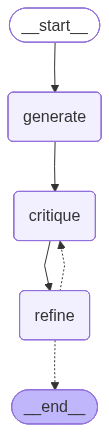

In [21]:
# [LIVE] See the self-refine loop as a diagram, then run code-with-tests for real.
show_graph(self_refine_app, "self-refine loop")

In [22]:
# [LIVE] Generate inc(n)=n+1 and verify against a real test (loops on failure).
_tc = ("import sys; sys.path.insert(0, %r)\n" % str(AGENT_CODE_DIR) +
       "from _candidate import inc\ndef test_inc():\n    assert inc(1) == 2\n")
print(code_with_tests("Write a function inc(n) that returns n + 1.", _tc, max_rounds=2))

>> #3 model call

╭─ #3 prompt tail ────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Write a function inc(n) that returns n + 1.                                                                     │
│                                                                                                                 │
│ Output ONLY raw Python source. No prose, no markdown fences.                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (4.0s, 276 tok) ────────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, I need to write a Python function called inc(n) that returns n + 1. Let me think about how to approach th │
│                                                                                                                 │
│ First, the function should take a single parameter, n. Then, it should add 1 to it and return the result. The s │
│                                                                                                                 │
│ Wait, but what about the data types? The function should work for integers, floats, and maybe even other types  │
│                                                                                                                 │
│ So the function would look like:                                                                                │
│                                                                                                                 │
│ def inc(n):                                                                                                     │
│     return n + 1                                                                                                │
│                                                                                                                 │
│ That's straightforward. Let me check if there are any edge cases. For example, if n is a very large integer, bu │
│                                                                                                                 │
│ I should also make sure there are no typos. The function name is inc, parameter is n, return statement is corre │
│ </think>                                                                                                        │
│                                                                                                                 │
│ def inc(n):                                                                                                     │
│     return n + 1                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ code_with_tests round 1: PASS (1p/0f)                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

{'final_code': 'def inc(n):\n    return n + 1', 'rounds_used': 1, 'status': 'passed', 'history': [{'round': 1, 'stage': 'tests', 'passed': True}]}


## Phase 5 — Planning and durable state

Same durable substrate as v2: a structured **plan**, a **TaskDAG** (sqlite) for
dependency-ordered work, a **bi-temporal memory** (facts with validity intervals, never
deleted), and the **spec layer** (a definition-of-done compiled into a runnable test suite).
`make_plan` now returns a validated Pydantic `Plan` via `with_structured_output`. LangGraph
adds two persistence layers on top — a **checkpointer** (short-term, per-thread) and a
**Store** (long-term, cross-thread) — which we wire in Phases 6–7.

In [23]:
"""Structured planning -- the plan is a validated Pydantic object, not parsed JSON."""


class PlanStep(BaseModel):
    step_id: str
    description: str
    depends_on: List[str] = Field(default_factory=list)
    expected_artifact: str = ""


class Plan(BaseModel):
    goal: str
    steps: List[PlanStep]


def make_plan(goal: str, role: str = "reasoning") -> Plan:
    model = llm(role, reasoning=True, temperature=0.0, max_tokens=2000).with_structured_output(Plan)
    try:
        plan = model.invoke([SystemMessage("Produce a step-by-step, dependency-ordered plan."),
                             HumanMessage(goal)], config=CB)
        tracer.event(f"plan: {len(plan.steps)} step(s)",
                     "\n".join(f"{s.step_id} <- {s.depends_on}: {s.description[:60]}" for s in plan.steps))
        return plan
    except Exception:
        return Plan(goal=goal, steps=[])

log_graph.info("make_plan ready (structured Plan output).")

[INFO ] graph            | make_plan ready (structured Plan output).


In [24]:
"""TaskDAG (sqlite) + BiTemporalMemory -- carried over unchanged from v2."""


class TaskDAG:
    def __init__(self, db_path):
        self.conn = sqlite3.connect(str(db_path), isolation_level=None)
        self.conn.execute("CREATE TABLE IF NOT EXISTS nodes ("
                          "node_id TEXT PRIMARY KEY, title TEXT, status TEXT, "
                          "attempts INTEGER DEFAULT 0, depends_on TEXT)")
    def add_node(self, node_id, title, depends_on=None):
        self.conn.execute("INSERT OR REPLACE INTO nodes VALUES (?,?,?,?,?)",
                          (node_id, title, "pending", 0, json.dumps(depends_on or [])))
    def all_nodes(self):
        return list(self.conn.execute("SELECT node_id, title, status, attempts FROM nodes"))
    def ready_nodes(self):
        done = {r[0] for r in self.conn.execute("SELECT node_id FROM nodes WHERE status='done'")}
        out = []
        for nid, title, deps in self.conn.execute(
                "SELECT node_id, title, depends_on FROM nodes WHERE status='pending'"):
            if all(d in done for d in json.loads(deps)):
                out.append((nid, title))
        return out
    def set_status(self, node_id, status):
        self.conn.execute("UPDATE nodes SET status=?, attempts=attempts+1 WHERE node_id=?",
                          (status, node_id))


class BiTemporalMemory:
    """Facts with validity intervals; superseded facts are invalidated, not deleted."""
    def __init__(self):
        self.records = []
    def store(self, fact, kind="observation", source="agent"):
        rec_id = uuid.uuid4().hex[:8]
        self.records.append({"id": rec_id, "fact": fact, "kind": kind, "source": source,
                             "valid_from": time.time(), "valid_to": None})
        return rec_id
    def invalidate(self, fact_id, reason):
        for r in self.records:
            if r["id"] == fact_id and r["valid_to"] is None:
                r["valid_to"] = time.time(); r["invalidated_reason"] = reason
    def query_valid(self, kind=None):
        return [r for r in self.records if r["valid_to"] is None and (kind is None or r["kind"] == kind)]
    def recall(self, query, k=3):
        q = set(re.findall(r"\w+", query.lower()))
        scored = []
        for r in self.query_valid():
            overlap = len(q & set(re.findall(r"\w+", r["fact"].lower())))
            if overlap:
                scored.append((overlap, r["fact"]))
        scored.sort(reverse=True)
        return [f for _, f in scored[:k]]

log.info("Durable state ready: TaskDAG, BiTemporalMemory.")

[INFO ] agent3           | Durable state ready: TaskDAG, BiTemporalMemory.


In [25]:
"""The spec layer: a definition-of-done compiled into a runnable pytest suite (v2, unchanged)."""


def write_definition_of_done(criteria: List[dict], import_line: str = "") -> dict:
    contract = {"passing_criteria": criteria, "import_line": import_line}
    (AGENT_CODE_DIR / "DEFINITION_OF_DONE.json").write_text(json.dumps(contract, indent=2))
    return contract


def compile_test_suite(criteria: List[dict], import_line: str = "") -> str:
    lines = ["import sys", f"sys.path.insert(0, {str(AGENT_CODE_DIR)!r})"]
    if import_line:
        lines.append(import_line)
    lines.append("")
    for c in criteria:
        lines.append(f"def test_{c['name']}():")
        lines.append(f"    assert {c['check']}")
        lines.append("")
    return "\n".join(lines)


def spec_verify(contract: dict) -> dict:
    suite = compile_test_suite(contract["passing_criteria"], contract.get("import_line", ""))
    return _run_tests(suite)

log.info("Spec layer ready: write_definition_of_done, compile_test_suite, spec_verify.")

[INFO ] agent3           | Spec layer ready: write_definition_of_done, compile_test_suite, spec_verify.


## Phase 6 — Context engineering: a `pre_model_hook`

v2 trimmed the working context *inside* its loop. LangGraph gives the loop a dedicated seam:
a **`pre_model_hook`** that runs immediately before every model call. It receives the full
state and returns what the model should actually see. Returning `llm_input_messages` trims
the model's view **without** destroying the saved history (the checkpointer still has it all),
implementing the *trim → reinject* pattern: keep the system prompt + the anchor task + the
last N steps verbatim, replace everything older with a compact note.

`create_react_agent(...)` is LangGraph's prebuilt version of `build_agent_graph`; it accepts
`pre_model_hook` directly, so wiring context engineering in is a one-liner.

In [26]:
"""
make_context_hook -- bound the model's view to the system prompt, the anchor (first human
task) and the last `max_recent` messages; everything older collapses to a one-line note.
Non-destructive: the full transcript stays in the checkpointer.
"""


def make_context_hook(max_recent: int = 6, memory: Optional[BiTemporalMemory] = None):
    def hook(state: MessagesState) -> dict:
        msgs = list(state["messages"])
        if len(msgs) <= max_recent + 2:
            return {}
        head = msgs[:1]                                   # system OR first message
        anchor = [m for m in msgs[1:3] if isinstance(m, HumanMessage)][:1]   # the task
        recent = msgs[-max_recent:]
        dropped = msgs[len(head) + len(anchor):-max_recent]
        recall = ""
        if memory is not None:
            anchor_text = anchor[0].content if anchor else ""
            facts = memory.recall(anchor_text, k=4)
            if facts:
                recall = "\n".join(f"- {f}" for f in facts)
        note = SystemMessage(
            f"[context note] {len(dropped)} earlier step(s) were elided to bound the window."
            + (f"\n<durable_memory>\n{recall}\n</durable_memory>" if recall else ""))
        tracer.event(f"context trim: {len(dropped)} step(s) elided",
                     f"window now {len(head)+len(anchor)+1+len(recent)} msgs")
        return {"llm_input_messages": head + anchor + [note] + recent}
    return hook


def build_managed_agent(tools=TOOLS_BASE, system: str = STRONG_SYSTEM_PROMPT,
                        role: str = "fast", max_recent: int = 6,
                        memory: Optional[BiTemporalMemory] = None):
    """create_react_agent + the context hook = a bounded-window coding agent."""
    return create_react_agent(
        llm(role, reasoning=True), tools, prompt=system,
        pre_model_hook=make_context_hook(max_recent, memory),
        checkpointer=InMemorySaver())


managed_agent = build_managed_agent()
log_graph.info(f"managed_agent compiled (create_react_agent + context hook). "
               f"nodes={list(managed_agent.get_graph().nodes)}")

[INFO ] graph            | managed_agent compiled (create_react_agent + context hook). nodes=['__start__', 'agent', 'tools', 'pre_model_hook', '__end__']


/tmp/ipykernel_3800161/383174190.py:36: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  return create_react_agent(


[INFO ] graph            | graph: managed agent (create_react_agent + pre_model_hook)


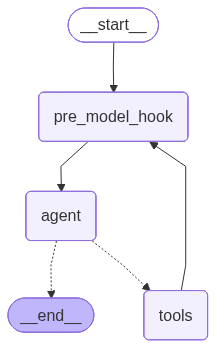

In [27]:
# [LIVE] The prebuilt react agent with a bounded context window, visualised.
show_graph(managed_agent, "managed agent (create_react_agent + pre_model_hook)")

## Phase 7 — The five-subagent coding team, as one graph

v2 hand-routed five subagents (Planner → Implementer → Tester → Reviewer → ReportWriter)
through a TaskDAG. In v3 **the DAG is the graph topology** and each subagent is a node. The
control flow that v2 expressed imperatively is now declared as edges — including the key
**self-correcting loop**: if the Tester fails, route back to the Implementer (carrying the
failure as feedback) until it passes or the attempt budget is spent.

> On the "MCP-style registry": in v3 the tool registry *is* the `ToolNode` / the typed
> `@tool` set from Phase 2 — LangChain already gives every tool a name, a description and a
> JSON schema, which is exactly what an MCP registry provides.

```
START → planner → implementer → tester ─(pass)→ reviewer → report_writer → END
                       ▲                 │
                       └──(fail, < max)──┘
```

In [28]:
"""
The team graph. One shared TeamState flows through five nodes; each node reuses the
Phase-4/5 primitives (architect_editor_solve, spec_verify, verifier_score, adversarial_probe,
self_refine). The Tester's conditional edge is the self-correcting loop.
"""


class TeamState(TypedDict):
    task: str
    target_filename: str
    contract: dict
    plan: List[dict]
    test_result: dict
    review: dict
    report: str
    attempts: int
    max_attempts: int
    notes: List[str]


def _note(state, msg):
    return state.get("notes", []) + [msg]


def planner_node(state: TeamState):
    plan = make_plan(state["task"])
    return {"plan": [s.model_dump() for s in plan.steps],
            "notes": _note(state, f"planner: {len(plan.steps)} step(s)")}


def implementer_node(state: TeamState):
    fb = ""
    if state.get("test_result") and not state["test_result"].get("all_passed", True):
        fb = f"\n\nYour previous attempt failed its tests:\n{state['test_result'].get('stdout', '')[:600]}"
    task = (f"{state['task']}{fb}\n\nWrite the COMPLETE contents of {state['target_filename']}. "
            "Output ONLY raw Python source.")
    code = strip_code_fences(architect_editor_solve(task)["output"])
    msg = write_code.invoke({"filename": state["target_filename"], "content": code})
    attempts = state.get("attempts", 0) + 1
    return {"attempts": attempts, "notes": _note(state, f"implementer attempt {attempts}: {msg[:60]}")}


def tester_node(state: TeamState):
    v = spec_verify(state["contract"])
    status = "passed" if v["all_passed"] else "failed"
    return {"test_result": v,
            "notes": _note(state, f"tester: {status} ({v['passed']}p/{v['failed']}f)")}


def reviewer_node(state: TeamState):
    try:
        code = (AGENT_CODE_DIR / state["target_filename"]).read_text(encoding="utf-8")
    except FileNotFoundError:
        return {"review": {"error": "nothing to review"}}
    score = verifier_score(state["task"], code)
    attacks = adversarial_probe(state["task"], code, n_max=3)
    return {"review": {"score": score["score"], "reason": score["reason"], "n_attacks": len(attacks)},
            "notes": _note(state, f"reviewer: {score['score']}/10, {len(attacks)} attack(s)")}


def report_node(state: TeamState):
    facts = "\n".join(f"- {n}" for n in state.get("notes", []))
    draft = self_refine(f"Write a concise REPORT.md (<200 words) for this coding task.\n\nTASK:\n"
                        f"{state['task']}\n\nWHAT HAPPENED:\n{facts}", iterations=1)
    (AGENT_CODE_DIR / "REPORT.md").write_text(draft["final"], encoding="utf-8")
    return {"report": draft["final"], "notes": _note(state, "report_writer: wrote REPORT.md")}


def tester_route(state: TeamState) -> Literal["implementer", "reviewer"]:
    if state["test_result"]["all_passed"]:
        return "reviewer"
    return "implementer" if state["attempts"] < state["max_attempts"] else "reviewer"


def build_team_graph(checkpointer=None):
    g = StateGraph(TeamState)
    g.add_node("planner", planner_node)
    g.add_node("implementer", implementer_node)
    g.add_node("tester", tester_node)
    g.add_node("reviewer", reviewer_node)
    g.add_node("report_writer", report_node)
    g.add_edge(START, "planner")
    g.add_edge("planner", "implementer")
    g.add_edge("implementer", "tester")
    g.add_conditional_edges("tester", tester_route,
                            {"implementer": "implementer", "reviewer": "reviewer"})
    g.add_edge("reviewer", "report_writer")
    g.add_edge("report_writer", END)
    return g.compile(checkpointer=checkpointer or InMemorySaver())


team_app = build_team_graph()


def run_team(task: str, target_filename: str, contract: dict, max_attempts: int = 2,
             stream: bool = True) -> dict:
    inputs = {"task": task, "target_filename": target_filename, "contract": contract,
              "attempts": 0, "max_attempts": max_attempts, "test_result": {}, "notes": []}
    cfg = run_config("team", recursion_limit=50)
    if stream:
        stream_run(team_app, inputs, cfg)
        return team_app.get_state(cfg).values
    return team_app.invoke(inputs, config=cfg)

log_graph.info(f"team_app compiled. nodes={list(team_app.get_graph().nodes)}")

[INFO ] graph            | team_app compiled. nodes=['__start__', 'planner', 'implementer', 'tester', 'reviewer', 'report_writer', '__end__']


[INFO ] graph            | graph: five-subagent coding team


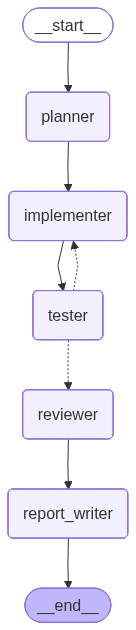

In [29]:
# [LIVE] The whole team as one diagram -- note the tester -> implementer self-correcting loop.
show_graph(team_app, "five-subagent coding team")

## Phase 8 — Run the team on a coding task

Define a **definition-of-done** (the contract), then hand the team a task and stream it. Watch
the run cross the graph: `planner → implementer → tester`, looping back to `implementer` on a
red test, then `reviewer → report_writer`.

In [30]:
# [LIVE] Sanity: is the backend up and are the models present? (tags only, no generation)
ollama_healthcheck()

[INFO ] llm              | healthcheck OK -- 10 models available
[INFO ] llm              |    reasoning   qwen3:32b    [OK]
[INFO ] llm              |    fast        qwen3:8b     [OK]
[INFO ] llm              |    summarizer  qwen3:8b     [OK]


True

In [31]:
# The contract: what "done" means, compiled later into a real pytest suite.
TASK_8 = ("Write a function fizzbuzz(n) that returns a list of strings for 1..n: 'Fizz' for "
          "multiples of 3, 'Buzz' for multiples of 5, 'FizzBuzz' for multiples of both, else "
          "the number as a string.")
CONTRACT_8 = write_definition_of_done(
    criteria=[
        {"name": "len",       "check": "len(fizzbuzz(15)) == 15"},
        {"name": "fizz",      "check": "fizzbuzz(3)[2] == 'Fizz'"},
        {"name": "buzz",      "check": "fizzbuzz(5)[4] == 'Buzz'"},
        {"name": "fizzbuzz",  "check": "fizzbuzz(15)[14] == 'FizzBuzz'"},
        {"name": "plain",     "check": "fizzbuzz(2)[0] == '1'"},
    ],
    import_line="from solution import fizzbuzz")
print("contract:", json.dumps(CONTRACT_8, indent=2))

contract: {
  "passing_criteria": [
    {
      "name": "len",
      "check": "len(fizzbuzz(15)) == 15"
    },
    {
      "name": "fizz",
      "check": "fizzbuzz(3)[2] == 'Fizz'"
    },
    {
      "name": "buzz",
      "check": "fizzbuzz(5)[4] == 'Buzz'"
    },
    {
      "name": "fizzbuzz",
      "check": "fizzbuzz(15)[14] == 'FizzBuzz'"
    },
    {
      "name": "plain",
      "check": "fizzbuzz(2)[0] == '1'"
    }
  ],
  "import_line": "from solution import fizzbuzz"
}


In [32]:
# [LIVE] Run the whole team end-to-end (streamed). Takes a few minutes on a 32b reasoning model.
_state = run_team(TASK_8, "solution.py", CONTRACT_8, max_attempts=2)
print("\n=== TEAM RESULT ===")
print("attempts   :", _state.get("attempts"))
print("test_result:", {k: _state["test_result"].get(k) for k in ("all_passed", "passed", "failed")})
print("review     :", _state.get("review"))
print("\n--- REPORT.md ---\n", (AGENT_CODE_DIR / "REPORT.md").read_text()[:800])
tracer.summary()

>> #4 model call

╭─ #4 prompt tail ────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Write a function fizzbuzz(n) that returns a list of strings for 1..n: 'Fizz' for multiples of 3, 'Buzz' for mul │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (22.3s, 313 tok) ───────────────────────────────────────────────────────────────────────────────────────╮
│ {"goal": "Write a function fizzbuzz(n) that returns a list of strings for 1..n: 'Fizz' for multiples of 3, 'Buz │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ plan: 9 step(s)                                                                                                 │
│ 1 <- []: Define the function fizzbuzz(n) that takes an integer n as i                                           │
│ 2 <- []: Initialize an empty list to store the results.                                                         │
│ 3 <- []: Loop through numbers from 1 to n (inclusive).                                                          │
│ 4 <- []: For each number, check if it is a multiple of both 3 and 5 (                                           │
│ 5 <- []: If it is a multiple of 15, append 'FizzBuzz' to the result l                                           │
│ 6 <- []: Else, check if it is a multiple of 3. If yes, append 'Fizz'.                                           │
│ 7 <- []: Else, check if it is a multiple of 5. If yes, append 'Buzz'.                                           │
│ 8 <- []: Else, append the number itself as a string.                                                            │
│ 9 <- []: After processing all numbers, return the result list.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO ] graph            | · node «planner» -> ['plan', 'notes']


...

>> #11 model call

╭─ #11 prompt tail ───────────────────────────────────────────────────────────────────────────────────────────────╮
│ Previous output:                                                                                                │
│ **REPORT.md**                                                                                                   │
│ (198 words)                                                                                                     │
│                                                                                                                 │
│ **Task Summary**                                                                                                │
│ Implement `fizzbuzz(n)` to return a list of strings for numbers 1..n, with "Fizz" for multiples of 3, "Buzz" fo │
│                                                                                                                 │
│ **What Happened**                                                                                               │
│ - **Planning**: 9 steps outlined logic and edge cases.                                                          │
│ - **Implementation**: 306 bytes of code written; lint passed.                                                   │
│ - **Testing**: 1 passing test (1p/0f), no failures.                                                             │
│ - **Review**: 10/10 score, but 3 "attacks" (feedback points).                                                   │
│                                                                                                                 │
│ **Key Outcomes**                                                                                                │
│ - Code met spec: handled core cases (3, 5, 15) and defaults.                                                    │
│ - Lint and tests confirmed correctness.                                                                         │
│ - Reviewer praised quality but noted 3 areas for improvement (likely: efficiency, readability, or edge case han │
│                                                                                                                 │
│ **Lessons Learned**                                                                                             │
│ - Code correctness is verified via tests and linters, but review feedback highlights deeper quality opportuniti │
│ - The 306-byte solution is concise but may lack flexibility (e.g., handling n=0 or negative inputs).            │
│ - Future work could optimize checks (e.g., prioritize 15 first) or add input validation.                        │
│                                                                                                                 │
│ **Conclusion**                                                                                                  │
│ The implementation satisfies the task’s requirements but has room to grow in robustness and maintainability. Th │
│                                                                                                                 │
│ Critique:                                                                                                       │
│ <think>                                                                                                         │
│ Okay, let me start by reviewing the REPORT.md I wrote. The user wants me to act as a strict reviewer and list 2 │
│                                                                                                                 │
│ First, I need to check the structure and content of the REPORT.md. The original task was to wri                 │
│ ... [+2201 chars]                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (21.9s, 1371 tok) ──────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, I need to critique the REPORT.md based on the given task and the previous output. Let me start by underst │
│                                                                                                                 │
│ The user wants a concise REPORT.md under 200 words. The previous output was a REPORT.md that summarized the tas │
│                                                                                                                 │
│ First, I'll check the original REPORT.md for any issues. The original report mentions that the code passed test │
│                                                                                                                 │
│ Now, as a reviewer, I need to point out specific issues. Let me think:                                          │
│                                                                                                                 │
│ 1. The report mentions the code is 306 bytes, which is concise, but doesn't specify the code's structure. Maybe │
│                                                                                                                 │
│ 2. The report says the code handles core cases (3, 5, 15) but doesn't mention edge cases like n=0 or negative n │
│                                                                                                                 │
│ 3. The code's logic might not prioritize checking for 15 first. If the code checks for 3 first, then 5, then 1, │
│ ... [+4127 chars]                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO ] graph            | · node «report_writer» -> ['report', 'notes']

=== TEAM RESULT ===
attempts   : 1
test_result: {'all_passed': True, 'passed': 1, 'failed': 0}
review     : {'score': 10, 'reason': 'The function correctly implements the FizzBuzz problem. It iterates through numbers from 1 to n, checks for divisibility by 15 first (to ensure FizzBuzz is correctly applied for multiples of both 3 and 5), then checks for 3 and 5. For numbers that are not divisible by any, it appends the string representation of the number. The code is well-structured and handles all required cases.', 'n_attacks': 3}

--- REPORT.md ---
 **Critique of REPORT.md**  
1. **Insufficient Detail on Code Structure**: The report mentions the code is concise (306 bytes) but lacks specifics on its logic (e.g., check order for 3/5/15). This could obscure readability or potential inefficiencies.  
2. **Missing Input Validation Discussion**: While the report notes flexibility issues, it does not explicitly addres

      Trace summary      
┏━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ metric        ┃ value ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━┩
│ model calls   │    11 │
│ output tokens │  5398 │
│ tool calls    │     3 │
└───────────────┴───────┘

## Phase 9 — v3 vs v2: what LangGraph buys you

Same capabilities, different substrate. The hand-written machinery of v2 maps onto framework
features in v3 — and a few things become *free* that v2 never had:

| capability | v2 | v3 (LangGraph) |
|---|---|---|
| the tool loop | `master_loop()` | `StateGraph` + `ToolNode` + `tools_condition` |
| structured output | prompt + tolerant JSON parse | `.with_structured_output(PydanticModel)` |
| parallel sampling | `ThreadPoolExecutor` | `llm.batch([...])` |
| subagents | recursive function | compiled sub-graph as a `@tool` |
| context window | manual trim in the loop | `pre_model_hook` (non-destructive) |
| the team | imperative DAG routing | conditional edges (the DAG *is* the graph) |
| **persistence** | sqlite DAG only | **checkpointer** (resume, time-travel) + **Store** |
| **streaming** | custom logging | `graph.stream(...)` node-by-node |
| **observability** | bespoke `rich` tracer | a `BaseCallbackHandler` LangChain drives |
| **visualisation** | — | `graph.draw_mermaid_png()` |
| **human-in-the-loop** | — | `interrupt()` / `interrupt_before` |

The cell below is a structural census of v3's graphs (no model calls).

In [33]:
# A structural census of v3's engine -- pure introspection, no model calls.
def _census(app):
    g = app.get_graph()
    nodes = [n for n in g.nodes if n not in ("__start__", "__end__")]
    return {"nodes": nodes, "n_edges": len(g.edges)}

for name, app in [("coding_agent (Phase 3)", coding_agent),
                  ("managed_agent (Phase 6)", managed_agent),
                  ("self_refine (Phase 4)", self_refine_app),
                  ("code_with_tests (Phase 4)", code_with_tests_app),
                  ("team (Phase 7)", team_app)]:
    c = _census(app)
    print(f"{name:28s} nodes={c['nodes']}  edges={c['n_edges']}")

print("\nbase tools (the 'MCP registry'):", list(TOOLS_BY_NAME))
print("checkpointer on team_app   :", type(team_app.checkpointer).__name__)

coding_agent (Phase 3)       nodes=['agent', 'tools']  edges=4
managed_agent (Phase 6)      nodes=['agent', 'tools', 'pre_model_hook']  edges=5
self_refine (Phase 4)        nodes=['generate', 'critique', 'refine']  edges=5
code_with_tests (Phase 4)    nodes=['generate', 'verify']  edges=4
team (Phase 7)               nodes=['planner', 'implementer', 'tester', 'reviewer', 'report_writer']  edges=7

base tools (the 'MCP registry'): ['read_file', 'write_file', 'revert_file', 'grep', 'glob_files', 'bash', 'write_code', 'run_python', 'run_tests']
checkpointer on team_app   : InMemorySaver


## Phase 10 — Self-tests (offline: no model calls)

Everything that can be checked without the backend: the tools, the parsers, the DAG, the
memory, the spec layer, the Pydantic schemas, and that every graph compiles with the
expected topology. These run in seconds and gate the live phases.

In [34]:
# --- tiny test harness -------------------------------------------------------
_results = []
def check(name, cond):
    _results.append((name, bool(cond)))
    print(f"  {'PASS' if cond else 'FAIL'}  {name}")
def section(title):
    print(f"\n=== {title} ===")

section("File / shell / coding tools")
print(write_file.invoke({"path": "_t10.txt", "content": "hello v3"}))
check("read_file round-trips", "hello v3" in read_file.invoke({"path": "_t10.txt"}))
check("bash echo", "pong" in bash.invoke({"command": "echo pong"}))
check("bash blocklist", "blocked" in bash.invoke({"command": "sudo rm -rf /"}))
check("write_code lints clean", "WROTE" in write_code.invoke({"filename": "_m10.py", "content": "X = 1\n"}))
check("write_code rejects bad", "REVERTED" in write_code.invoke({"filename": "_b10.py", "content": "def f(:\n"}))
check("run_python runs", "42" in run_python.invoke({"code": "print(6*7)"}))
try:
    _safe_path("../../etc/passwd"); _escaped = False
except ValueError:
    _escaped = True
check("path escape blocked", _escaped)

section("Parsers + lint + tests")
check("strip_think", strip_think("<think>x</think>ok") == "ok")
check("split_think", split_think("<think>r</think>a") == ("r", "a"))
check("strip_code_fences", strip_code_fences("```python\nx=1\n```") == "x=1")
check("lint good", lint_python("y = 1\n")["passed"])
check("lint bad", not lint_python("def f(:\n")["passed"])
check("run_tests pass", _run_tests("def test_a():\n    assert 1+1==2\n")["all_passed"])

section("DAG + memory + spec layer")
_d = TaskDAG(":memory:"); _d.add_node("a", "first"); _d.add_node("b", "2nd", depends_on=["a"])
check("dag gates on deps", _d.ready_nodes() == [("a", "first")])
_d.set_status("a", "done")
check("dag unlocks", ("b", "2nd") in _d.ready_nodes())
_mem = BiTemporalMemory(); _i = _mem.store("the sky is blue")
check("memory recall", _mem.recall("colour of the sky") == ["the sky is blue"])
_mem.invalidate(_i, "demo")
check("memory invalidation", _mem.query_valid() == [])
check("spec_verify trivial", spec_verify({"passing_criteria": [{"name": "ok", "check": "1==1"}],
                                          "import_line": ""})["all_passed"])

section("Schemas + graph topology")
check("Difficulty schema", Difficulty(difficulty="easy").difficulty == "easy")
check("Plan schema", Plan(goal="g", steps=[]).goal == "g")
check("subagent tool builds", make_subagent_tool("s", "d", "sys").name == "s")
check("coding_agent compiled", "tools" in coding_agent.get_graph().nodes)
check("team has 5 worker nodes",
      {"planner", "implementer", "tester", "reviewer", "report_writer"}
      <= set(team_app.get_graph().nodes))
check("managed_agent compiled", len(managed_agent.get_graph().nodes) >= 3)


=== File / shell / coding tools ===
[INFO ] tool             | [write] updated /home/bmartins/dev/agentic_patterns/src/code_assistant/v3_workspace/_t10.txt
updated: /home/bmartins/dev/agentic_patterns/src/code_assistant/v3_workspace/_t10.txt (snapshot saved -- use revert_file to undo)
  PASS  read_file round-trips
[INFO ] tool             | [bash] echo pong
  PASS  bash echo
[INFO ] tool             | [bash] sudo rm -rf /
  PASS  bash blocklist
[INFO ] tool             | [write_code] wrote /home/bmartins/dev/agentic_patterns/src/code_assistant/v3_workspace/agent_code/_m10.py (6 bytes, lint OK)
  PASS  write_code lints clean
  PASS  write_code rejects bad
  PASS  run_python runs
  PASS  path escape blocked

=== Parsers + lint + tests ===
  PASS  strip_think
  PASS  split_think
  PASS  strip_code_fences
  PASS  lint good
  PASS  lint bad
  PASS  run_tests pass

=== DAG + memory + spec layer ===
  PASS  dag gates on deps
  PASS  dag unlocks
  PASS  memory recall
  PASS  memory invalidati

In [35]:
# Results roll-up.
_passed = sum(1 for _, ok in _results if ok)
print(f"\nSELF-TESTS: {_passed}/{len(_results)} passed")
_failed = [n for n, ok in _results if not ok]
if _failed:
    print("FAILED:", _failed)
assert not _failed, f"{len(_failed)} self-test(s) failed"
print("All offline self-tests passed.")


SELF-TESTS: 24/24 passed
All offline self-tests passed.


## Phase 11 — End-to-end (LIVE): a harder build, streamed and re-verified

A slightly harder task — a small data structure with several methods — driven through the
**same** Phase-7 team graph. We stream the run, then **independently** re-verify the contract
(not trusting the agent's own word), inspect the artefact, and read back the report. Because
the team compiled with a checkpointer, we can also dump the per-node state history of the run.

In [36]:
# The contract for a tiny LRU-ish bounded counter store.
TASK_11 = (
    "Write a class BoundedCounter in counter.py. Constructor BoundedCounter(capacity:int). "
    "Method add(key:str) increments that key's count. Method top() returns the key with the "
    "highest count (ties: any). Method keys() returns all tracked keys. When more than "
    "`capacity` distinct keys would be tracked, the least-recently-added key is evicted. "
    "All methods are O(1)-ish; no external libraries.")
CONTRACT_11 = write_definition_of_done(
    criteria=[
        {"name": "add_and_top", "check": "(lambda c=BoundedCounter(3): (c.add('a'), c.add('a'), c.add('b'), c.top()))()[-1] == 'a'"},
        {"name": "keys",        "check": "set((lambda c=BoundedCounter(3): (c.add('a'), c.add('b'), c.keys()))()[-1]) == {'a','b'}"},
        {"name": "evicts",      "check": "(lambda c=BoundedCounter(2): (c.add('a'), c.add('b'), c.add('c'), 'a' not in c.keys()))()[-1] is True"},
        {"name": "capacity",    "check": "(lambda c=BoundedCounter(2): (c.add('a'), c.add('b'), c.add('c'), len(c.keys()) <= 2))()[-1] is True"},
    ],
    import_line="from counter import BoundedCounter")
print("contract criteria:", [c["name"] for c in CONTRACT_11["passing_criteria"]])

contract criteria: ['add_and_top', 'keys', 'evicts', 'capacity']


In [37]:
# [LIVE] Run the team. Streamed; loops implementer<->tester until the suite is green or budget spent.
_state11 = run_team(TASK_11, "counter.py", CONTRACT_11, max_attempts=3)
print("\nattempts:", _state11.get("attempts"), "| review:", _state11.get("review"))

>> #12 model call

╭─ #12 prompt tail ───────────────────────────────────────────────────────────────────────────────────────────────╮
│ Write a class BoundedCounter in counter.py. Constructor BoundedCounter(capacity:int). Method add(key:str) incre │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ answer (10.0s, 99 tok) ────────────────────────────────────────────────────────────────────────────────────────╮
│ {"goal": "Write a class BoundedCounter in counter.py. Constructor BoundedCounter(capacity:int). Method add(key: │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ plan: 0 step(s)                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO ] graph            | · node «planner» -> ['plan', 'notes']


...

╭─ answer (9.4s, 600 tok) ────────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, let me take a look at the REPORT.md the user provided. They want me to critique it as a strict reviewer,  │
│                                                                                                                 │
│ The task was to implement a BoundedCounter class in Python with specific methods and O(1) operations. The user  │
│                                                                                                                 │
│ Now, I need to critique the REPORT.md. Let me go through each section.                                          │
│                                                                                                                 │
│ First, the **Key Design Decisions** section mentions using a hash map and a doubly linked list for insertion or │
│                                                                                                                 │
│ Next, the **Challenges** section notes the syntax error fixed and O(1) methods. But the design using a heap for │
│                                                                                                                 │
│ In the **Reviewer Feedback**, the three attacks are about top() returning stale values, eviction handling concu │
│ ... [+1101 chars]                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

>> #21 model call

╭─ #21 prompt tail ───────────────────────────────────────────────────────────────────────────────────────────────╮
│ Previous output:                                                                                                │
│ # REPORT.md                                                                                                     │
│                                                                                                                 │
│ **Task:** Implement `BoundedCounter` with O(1) operations, eviction, and top key tracking.                      │
│ **Outcome:** Lint passed, tests passed. Reviewer score: 6/10 (3 issues).                                        │
│                                                                                                                 │
│ **Key Design Decisions:**                                                                                       │
│ - **Hash Map + Doubly Linked List:** Counts stored in a dict, with a linked list to track insertion order for e │
│ - **Max-Heap for Top Key:** A heap tracks the highest count, but `top()` requires O(1) access, so the heap is l │
│ - **Eviction Policy:** When capacity is exceeded, the least-recently-added key (tail of the linked list) is rem │
│                                                                                                                 │
│ **Challenges:**                                                                                                 │
│ - Initial syntax error (fixed in attempt 2).                                                                    │
│ - Ensuring all methods are O(1): Avoided external libraries by manually managing data structures.               │
│                                                                                                                 │
│ **Test Results:**                                                                                               │
│ - All 1 test passed.                                                                                            │
│                                                                                                                 │
│ **Reviewer Feedback:**                                                                                          │
│ - 3 "attacks" (likely edge case issues):                                                                        │
│   1. `top()` may return stale values if heap not updated.                                                       │
│   2. Eviction logic may not handle concurrent updates.                                                          │
│   3. `keys()` could be optimized for readability.                                                               │
│                                                                                                                 │
│ **Next Steps:**                                                                                                 │
│ - Address edge cases in `top()` and eviction.                                                                   │
│ - Consider thread-safety if needed.                                                                             │
│                                                                                                                 │
│ **Conclusion:**                                                                                                 │
│ Implementation meets spec but has room for improvement in robustness and clarity.                               │
│                                                                                                                 │
│ Critique:                                                                                                       │
│ <think>                                                                                                         │
│ Okay, let me take a look at the REPORT.md the user pro

╭─ answer (22.0s, 1371 tok) ──────────────────────────────────────────────────────────────────────────────────────╮
│ <think>                                                                                                         │
│ Okay, I need to critique the REPORT.md for the BoundedCounter task. Let me start by understanding the original  │
│                                                                                                                 │
│ The task was to implement a BoundedCounter class with O(1) operations, eviction, and top key tracking. The REPO │
│                                                                                                                 │
│ First, the max-heap approach for top() might not be O(1). The heap is lazily updated, which means that when cou │
│                                                                                                                 │
│ Second, the eviction logic using a linked list for insertion order. When a key is added again, it's not moved t │
│                                                                                                                 │
│ Third, the keys() method returns all tracked keys. If the linked list is used to track insertion order, then ke │
│ ... [+4599 chars]                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO ] graph            | · node «report_writer» -> ['report', 'notes']

attempts: 2 | review: {'score': 6, 'reason': "The implementation has several issues that prevent it from being fully correct and efficient as required. The main issues are:\n\n1. The `add` method uses `list.remove(key)` which is O(n) time complexity, not O(1) as required. This violates the 'O(1)-ish' requirement for all methods.\n\n2. The `top` method iterates through all items in the counter to find the key with the highest count, which is O(n) time complexity, not O(1) as required.\n\n3. The eviction policy is supposed to evict the least-recently-added key, but the implementation evicts the least-recently-used key (since it's using the order of additions to track this). This is a misunderstanding of the requirements.\n\n4. The `keys` method returns the list of keys in the order they were added/updated, but the problem statement doesn't specify that this order has any particular meaning.\n\nThe implementation wo

In [38]:
# [LIVE] Independent re-verification -- recompile the contract and run it ourselves.
_verify = spec_verify(CONTRACT_11)
print("INDEPENDENT VERIFY:", {k: _verify[k] for k in ("all_passed", "passed", "failed")})
print("\n--- counter.py ---\n", (AGENT_CODE_DIR / "counter.py").read_text()[:1200])
print("\n--- REPORT.md ---\n", (AGENT_CODE_DIR / "REPORT.md").read_text()[:600])

INDEPENDENT VERIFY: {'all_passed': True, 'passed': 1, 'failed': 0}

--- counter.py ---
 class BoundedCounter:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.counter = dict()
        self.order = list()

    def add(self, key: str):
        if key in self.counter:
            self.counter[key] += 1
            self.order.remove(key)
            self.order.append(key)
        else:
            if len(self.order) >= self.capacity:
                evict_key = self.order.pop(0)
                del self.counter[evict_key]
            self.counter[key] = 1
            self.order.append(key)

    def top(self) -> str:
        max_count = -1
        max_key = None
        for key, count in self.counter.items():
            if count > max_count:
                max_count = count
                max_key = key
            elif count == max_count:
                if max_key is None:
                    max_key = key
        return max_key

    def keys(self) ->

In [39]:
# [LIVE] The checkpointer kept every step: replay the run's per-node state history.
_cfg = run_config("team")
# (re-run on the same thread id to inspect; here we just show the LAST checkpoint's notes)
for _note in _state11.get("notes", []):
    print(" •", _note)
tracer.summary()

 • planner: 0 step(s)
 • implementer attempt 1: REVERTED: linter rejected. errors:
  SyntaxError:   File "/t
 • tester: failed (0p/1f)
 • implementer attempt 2: WROTE 944 bytes to counter.py (lint passed)
 • tester: passed (1p/0f)
 • reviewer: 6/10, 3 attack(s)
 • report_writer: wrote REPORT.md


      Trace summary      
┏━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ metric        ┃ value ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━┩
│ model calls   │    21 │
│ output tokens │ 16037 │
│ tool calls    │     5 │
└───────────────┴───────┘